In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [ ]:
#AT => Temperarure
#V => vaccum
#AP => pressure
#RH => humidity
#PE => product energy

In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
x = df.drop("PE",axis=1)
y= df["PE"]

In [7]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [9]:
#split data
from sklearn.model_selection import train_test_split
x_train, x_test , y_train, y_test = train_test_split(
x,y, test_size =0.2, random_state =42
)

In [10]:
df.shape

(9568, 5)

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [12]:
x_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

In [45]:
import torch
import torch.nn as nn

x_train_tensor = torch.tensor(x_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
x_test_tensor = torch.tensor(x_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [14]:
type(x_train_scaled)

numpy.ndarray

In [15]:
type(y_train)

pandas.core.series.Series

In [46]:
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

In [47]:
train_loader = DataLoader(train_dataset, batch_size = 32,shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32)

       --------   Deep learning  ---------

In [48]:
#ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1rst hiddem
            nn.Linear(x_train.shape[1], 6),
            nn.ReLU() ,

            # 2nd hiddem
            nn.Linear(6, 6),
            nn.ReLU() ,

            #output layer 
            nn.Linear(6,1)
        
    )
    def forward(self, x):
        return self.model(x)

In [49]:
import torch.optim as optim
model = ANN()

#loss optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [50]:
#training ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch
    
    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = crietrion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update
        
        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt or .pth

epoch 1/100 ==> train loss = 206284.71263020832 & val loss = 204440.390625
epoch 2/100 ==> train loss = 197078.65553385418 & val loss = 183932.703125
epoch 3/100 ==> train loss = 156443.5697265625 & val loss = 123242.7421875
epoch 4/100 ==> train loss = 87964.73787434895 & val loss = 57210.0234375
epoch 5/100 ==> train loss = 39486.23319498698 & val loss = 28505.595703125
epoch 6/100 ==> train loss = 24432.026525878908 & val loss = 21620.150390625
epoch 7/100 ==> train loss = 19774.363330078126 & val loss = 17799.28515625
epoch 8/100 ==> train loss = 16090.837599690754 & val loss = 14133.4091796875
epoch 9/100 ==> train loss = 12515.491410319011 & val loss = 10594.048828125
epoch 10/100 ==> train loss = 9048.09833984375 & val loss = 7299.80517578125
epoch 11/100 ==> train loss = 6033.7009552001955 & val loss = 4711.50048828125
epoch 12/100 ==> train loss = 3846.3888483683268 & val loss = 2985.252197265625
epoch 13/100 ==> train loss = 2403.2606755574543 & val loss = 1854.4534912109375


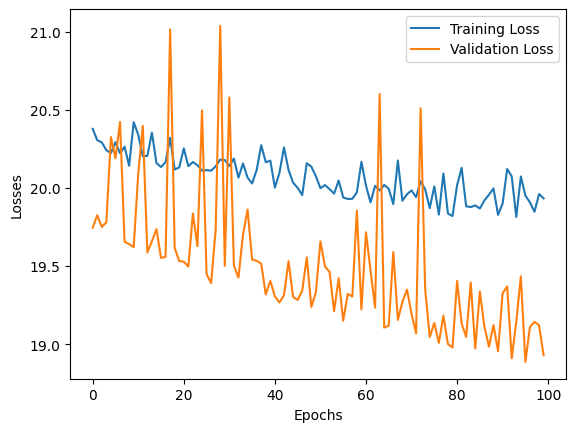

In [42]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [51]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [52]:
# Evaluation

model.eval()
with torch.no_grad():
    train_preds = model(x_train_tensor)
    test_preds = model(x_test_tensor)

    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 20.224349975585938
Testing MSE: 18.657289505004883


In [53]:
from sklearn.metrics import r2_score

print("r^2 score =", r2_score(y_test, test_preds))

r^2 score = 0.9347975922289027


In [55]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.153015,433.27
1,436.824829,438.16
2,461.889313,458.42
3,476.838715,480.82
4,435.644135,441.41
...,...,...
1909,451.317810,456.70
1910,431.536713,438.04
1911,467.623627,467.80
1912,430.982300,437.14
